<a href="https://colab.research.google.com/github/gustavolasantos-boop/CP1_SERS_ANALISE_DE_DADOS/blob/main/CP1_SERS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Dataset 1 — Appliances Energy Prediction (UCI)**

Fonte: https://archive.ics.uci.edu/dataset/374/appliances+energy+prediction

Situação

Uma empresa de eficiência energética está analisando o comportamento de uma residência de baixo consumo. A equipe deseja identificar períodos de consumo elevado dos eletrodomésticos e observar quais condições de temperatura e umidade estavam presentes nesses momentos.

"Ler todos os detalhes do DATASET no site"
"Desativar a opção add type anottatios to header no SAVE do orange"
"No ultimo ponto ao final de cada etapa pode utilizar o gemini para tirar conclusões"

untitled.svg

In [ ]:
import pandas as pd
df1 = pd.read_csv("/energydata_SAMPLE.csv")

In [ ]:
df1.head()

,Appliances,lights,T1,T2,T3,RH_1,RH_2,RH_3
0,40,0,20.8900,17.7600,20.2900,35.4000,39.1633,36.9000
1,90,10,21.8900,21.2900,21.6333,53.1000,45.3600,49.2267
2,50,0,21.3900,17.6333,21.6667,35.5000,40.5300,35.2000
3,50,0,21.3900,23.8900,22.0333,41.0333,34.8400,36.9333
4,70,0,19.9633,16.4633,20.0000,35.1267,40.1267,36.4000


In [ ]:
print(f"Número de linhas: {df1.shape[0]}")
print(f"Número de Colunas: {df1.shape[1]}")

Número de linhas: 1974
Número de Colunas: 8


In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1974 entries, 0 to 1973
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Appliances  1974 non-null   int64  
 1   lights      1974 non-null   int64  
 2   T1          1974 non-null   float64
 3   T2          1974 non-null   float64
 4   T3          1974 non-null   float64
 5   RH_1        1974 non-null   float64
 6   RH_2        1974 non-null   float64
 7   RH_3        1974 non-null   float64
dtypes: float64(6), int64(2)
memory usage: 123.5 KB


In [ ]:
df1.describe()

,Appliances,lights,T1,T2,T3,RH_1,RH_2,RH_3
count,1974.000000,1974.000000,1974.000000,1974.000000,1974.000000,1974.000000,1974.000000,1974.000000
mean,93.044580,3.839919,21.664703,20.293635,22.231615,40.219193,40.411386,39.209733
std,93.826149,7.937076,1.574883,2.126958,1.957275,3.971923,4.037686,3.288818
min,20.000000,0.000000,16.790000,16.100000,17.200000,27.733300,24.063300,30.133300
25%,50.000000,0.000000,20.700000,18.790000,20.700000,37.205825,37.760000,36.900000
50%,60.000000,0.000000,21.600000,20.000000,22.100000,39.590000,40.433300,38.433300
75%,100.000000,0.000000,22.600000,21.500000,23.290000,42.991675,43.228325,41.741250
max,770.000000,50.000000,26.260000,28.917500,29.198600,57.496700,56.026700,49.226700


In [ ]:
df1.columns

Index(['Appliances', 'lights', 'T1', 'T2', 'T3', 'RH_1', 'RH_2', 'RH_3'], dtype='object')

In [ ]:
# 2. Renomeio Appliances para Consumo_Eletrodomesticos e simplifique
# o nome de pelo menos três atributos ambientais.
df1.rename(columns={'Appliances':  'Consumo_Eletrodomesticos',
                    'T1' : 'Temperatura_01',
                    'RH_1' : 'Umidade_01',
                    'T2' : 'Temperatura_02',
                    'RH_2' : 'Umidade_02',
                    'T3' : 'Temperatura_03',
                    'RH_3' : 'Umidade_03'}, inplace = True)
df1.head()

,Consumo_Eletrodomesticos,lights,Temperatura_01,Temperatura_02,Temperatura_03,Umidade_01,Umidade_02,Umidade_03
0,40,0,20.8900,17.7600,20.2900,35.4000,39.1633,36.9000
1,90,10,21.8900,21.2900,21.6333,53.1000,45.3600,49.2267
2,50,0,21.3900,17.6333,21.6667,35.5000,40.5300,35.2000
3,50,0,21.3900,23.8900,22.0333,41.0333,34.8400,36.9333
4,70,0,19.9633,16.4633,20.0000,35.1267,40.1267,36.4000


In [ ]:
# Determine o maior consumo de eletrodomésticos registrado na amostra.
CMAX1 = df1['Consumo_Eletrodomesticos'].max()
print(f'A demanda máxima é {CMAX1:.2f} KW')


A demanda máxima é 770.00 KW


In [ ]:
# Calcule um limiar correspondente a 70% do valor máximo e crie um DataFrame contendo somente os registros acima desse limite
P70 = 0.7 * CMAX1
print(f'O limiar de 70% da demanda máxima é {P70:.2f} KW')

O limiar de 70% da demanda máxima é 539.00 KW


In [ ]:
#Crie um DataFrame contendo os registros acima desse limiar e calcule a quantidade e o percentual de registros
df2 = df1[df1['Consumo_Eletrodomesticos']> P70]
df2.head()

,Consumo_Eletrodomesticos,lights,Temperatura_01,Temperatura_02,Temperatura_03,Umidade_01,Umidade_02,Umidade_03
352,620,0,24.3900,25.3700,26.7300,44.3333,37.7360,38.8633
427,650,0,20.8900,18.2900,21.2000,36.7000,39.6633,36.0000
453,560,30,21.3567,19.5667,21.6333,36.0900,37.1633,35.0300
616,570,10,24.8900,23.5600,23.6000,32.6667,31.1400,30.8233
696,590,30,19.8567,18.7000,18.4267,47.6633,34.1000,37.8333


In [ ]:
df2.shape

(22, 8)

In [ ]:
porcentagem = 22/1974 * 100

In [ ]:

print(f'A porcentagem da amostra que representa acima dos valores de 70% é: {porcentagem:.2f} %')

A porcentagem da amostra que representa acima dos valores de 70% é: 1.11 %


In [ ]:
#Calcule a temperatura média de T1 e crie outro DataFrame contendo simultaneamente consumo acima de 70% do máximo e temperatura acima da média
df1['Temperatura_01'].mean()

np.float64(21.664702634245188)

In [ ]:
df3 = df1[(df1['Consumo_Eletrodomesticos']> P70) & (df1['Temperatura_01']> df1['Temperatura_01'].mean()) ]

In [ ]:
df3.head()

,Consumo_Eletrodomesticos,lights,Temperatura_01,Temperatura_02,Temperatura_03,Umidade_01,Umidade_02,Umidade_03
352,620,0,24.3900,25.3700,26.73,44.3333,37.7360,38.8633
616,570,10,24.8900,23.5600,23.60,32.6667,31.1400,30.8233
916,750,30,22.4300,21.9267,21.23,43.0000,40.1333,42.5967
993,690,10,22.5333,22.0667,22.39,45.0267,39.7900,41.9300
1182,600,20,24.8900,28.9175,27.10,48.1333,37.9475,42.4400


In [ ]:
df3.shape

(8, 8)

# Compare os dois DataFrames e explique o efeito da inclusão da temperatura como segundo critério --

 O efeito da inclusão da temperatura como segundo critério foi uma redução significativa no número de registros, de 22 para 8. Isso significa que, ao adicionar a condição de temperatura, estamos filtrando ainda mais os momentos de alto consumo, focando apenas naqueles em que a temperatura ambiente (Temperatura_01) também estava elevada. Isso é útil para identificar situações de alto consumo que podem estar relacionadas a um ambiente mais quente, o que pode indicar diferentes padrões de uso ou necessidades de eficiência energética

##**Dataset 2 — Steel Industry Energy Consumption (UCI)**

Fonte: https://archive.ics.uci.edu/dataset/851/steel+industry+energy+consumption

Situação

A equipe de gestão de energia de uma indústria siderúrgica deseja localizar situações de consumo elevado e verificar se esses períodos coincidem com condições de carga elevada ou valores menos favoráveis de fator de potência.

untitled.svg

In [ ]:
d2f1 = pd.read_csv("/content/Steel_industry_SAMPLE.csv")

In [ ]:
d2f1.rename(columns={'Usage_kWh':  'Consumo_kWh',
                    'WeekStatus' : 'Tipo_De_Dia',
                    'Day_of_week' : 'Dia_Semana',
                     'Load_Type': 'Tipo_Carga',
                     'Lagging_Current_Power_Factor': 'Fator_Potencia_Atrasado',
                     'Leading_Current_Power_Factor': 'Fator_Potencia_Adiantado'}, inplace = True)

In [ ]:
d2f1.head()

,Consumo_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,Fator_Potencia_Atrasado,Fator_Potencia_Adiantado,Tipo_De_Dia,Dia_Semana,Tipo_Carga
0,2.88,3.82,0.0,60.20,100.00,Weekend,Sunday,Light_Load
1,60.77,48.02,0.0,78.46,100.00,Weekday,Thursday,Maximum_Load
2,120.42,59.65,0.0,89.61,100.00,Weekday,Friday,Maximum_Load
3,3.13,0.00,16.6,100.00,18.53,Weekend,Saturday,Light_Load
4,58.86,20.99,0.0,94.19,100.00,Weekday,Friday,Medium_Load


In [ ]:
d2f1.shape

(7008, 8)

In [ ]:
d2f1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7008 entries, 0 to 7007
Data columns (total 8 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Consumo_kWh                           7008 non-null   float64
 1   Lagging_Current_Reactive.Power_kVarh  7008 non-null   float64
 2   Leading_Current_Reactive_Power_kVarh  7008 non-null   float64
 3   Fator_Potencia_Atrasado               7008 non-null   float64
 4   Fator_Potencia_Adiantado              7008 non-null   float64
 5   Tipo_De_Dia                           7008 non-null   object 
 6   Dia_Semana                            7008 non-null   object 
 7   Tipo_Carga                            7008 non-null   object 
dtypes: float64(5), object(3)
memory usage: 438.1+ KB


In [ ]:
d2f1.describe()

,Consumo_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,Fator_Potencia_Atrasado,Fator_Potencia_Adiantado
count,7008.000000,7008.000000,7008.000000,7008.000000,7008.000000
mean,27.790164,13.206839,3.803711,80.672277,84.491448
std,33.717719,16.444246,7.356412,18.869855,30.314798
min,2.450000,0.000000,0.000000,37.870000,12.710000
25%,3.200000,2.380000,0.000000,63.602500,99.710000
50%,4.570000,5.040000,0.000000,87.990000,100.000000
75%,52.107500,22.977500,1.857500,98.842500,100.000000
max,153.140000,87.700000,27.650000,100.000000,100.000000


In [ ]:
CMAX2 = d2f1['Consumo_kWh'].max()
print(f'O consumo máximo é {CMAX2:.2f} kW')

O consumo máximo é 153.14 kW


In [ ]:
C75 = 0.75 * CMAX2
print(f'O limiar de 75% do consumo máximo é {C75:.2f} kW')

O limiar de 75% do consumo máximo é 114.85 kW


In [ ]:
d2f2 = d2f1[d2f1['Consumo_kWh'] > C75].copy()
d2f2.head()

,Consumo_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,Fator_Potencia_Atrasado,Fator_Potencia_Adiantado,Tipo_De_Dia,Dia_Semana,Tipo_Carga
2,120.42,59.65,0.0,89.61,100.0,Weekday,Friday,Maximum_Load
62,118.22,54.04,0.0,90.95,100.0,Weekday,Thursday,Medium_Load
100,129.13,46.58,0.0,94.07,100.0,Weekday,Monday,Medium_Load
108,117.07,46.44,0.0,92.95,100.0,Weekday,Monday,Medium_Load
159,139.57,58.90,0.0,92.13,100.0,Weekday,Thursday,Maximum_Load


In [ ]:
print(f'Temos {d2f2.shape[0]} consumidores acima do limiar de 75% do consumo máximo')

Temos 129 consumidores acima do limiar de 75% do consumo máximo


In [ ]:
d2f2[d2f2['Tipo_Carga'] == 'Maximum_Load'].shape[0]

62

In [ ]:
limite = d2f2['Fator_Potencia_Atrasado'].quantile(0.25)  # 63.60

d2f2['FP_Baixo'] = d2f2['Fator_Potencia_Atrasado'] < limite

In [ ]:
d2f2['FP_Baixo'].value_counts()

,count
FP_Baixo,
False,97
True,32


In [ ]:
d2f3 = d2f2[d2f2['FP_Baixo']]
d2f3.head()

,Consumo_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,Fator_Potencia_Atrasado,Fator_Potencia_Adiantado,Tipo_De_Dia,Dia_Semana,Tipo_Carga,FP_Baixo
399,122.94,69.26,0.0,87.13,100.0,Weekday,Tuesday,Maximum_Load,True
771,132.30,70.06,0.0,88.37,100.0,Weekend,Saturday,Medium_Load,True
977,118.66,69.26,0.0,86.36,100.0,Weekday,Friday,Light_Load,True
1058,117.40,62.35,0.0,88.32,100.0,Weekday,Tuesday,Maximum_Load,True
1084,115.24,60.62,0.0,88.50,100.0,Weekday,Thursday,Maximum_Load,True


Com base na análise, o segundo conjunto de registros (representado por d2f3) merece maior atenção da equipe de energia por estas razões: ele identifica situações de alto consumo (Consumo_kWh acima de 75% do máximo) e baixo fator de potência (Fator_Potencia_Atrasado abaixo do quartil inferior). Essa combinação é crítica, pois indica ineficiência energética, o que pode levar a custos operacionais mais altos e possíveis multas por parte da distribuidora de energia. Ao focar nesses registros, a equipe pode investigar as causas do baixo fator de potência durante períodos de pico de consumo e implementar medidas corretivas para otimizar o uso de energia e reduzir despesas.

#**Dataset 3 - Power Comsumption of Tetouan City**

Fonte: https://archive.ics.uci.edu/dataset/849/power+consumption+of+tetouan+city

Situação

Uma equipe responsável pelo planejamento da distribuição de energia em Tétouan deseja identificar qual das três zonas apresenta o maior pico de consumo e observar as condições ambientais registradas nos momentos de maior demanda.

In [ ]:
import pandas as pd
d3f1 = pd.read_csv("/Tetuan City power consumption SAMPLE.csv")

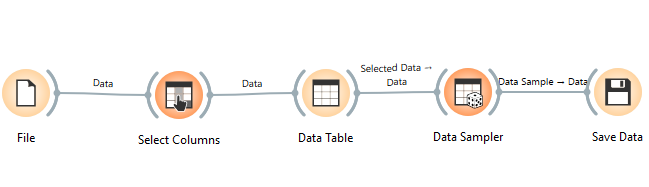

In [ ]:
# Inspeção inicial
print("PRIMEIRAS LINHAS:")
display(d3f1.head())

PRIMEIRAS LINHAS:


,Temperature,Humidity,Wind Speed,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption
0,22.76,29.73,0.085,32985.14532,19396.7,17623.3
1,15.92,54.44,0.085,34737.64259,29803.0,14417.3
2,15.08,57.23,0.076,27894.68354,20808.5,16458.8
3,12.42,72.30,0.081,42476.93617,23634.1,25089.7
4,14.58,80.60,0.080,21341.14101,12006.1,11531.6


In [ ]:
print("\nDIMENSÕES:")
print(f"Número de linhas: {d3f1.shape[0]}")
print(f"Número de colunas: {d3f1.shape[1]}")



DIMENSÕES:
Número de linhas: 7863
Número de colunas: 6


In [ ]:
print("\nESTRUTURA:")
d3f1.info()


ESTRUTURA:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7863 entries, 0 to 7862
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Temperature                7863 non-null   float64
 1   Humidity                   7863 non-null   float64
 2   Wind Speed                 7863 non-null   float64
 3   Zone 1 Power Consumption   7863 non-null   float64
 4   Zone 2  Power Consumption  7863 non-null   float64
 5   Zone 3  Power Consumption  7863 non-null   float64
dtypes: float64(6)
memory usage: 368.7 KB


In [ ]:
print("\nESTATÍSTICAS:")
display(d3f1.describe())



ESTATÍSTICAS:


,Temperature,Humidity,Wind Speed,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption
count,7863.000000,7863.000000,7863.000000,7863.000000,7863.000000,7863.000000
mean,18.789376,68.400612,1.965602,32371.549651,21060.733609,17845.600069
std,5.864564,15.665773,2.350954,7134.686966,5202.357437,6573.203996
min,3.541000,13.340000,0.054000,14612.658230,9436.250000,6211.760000
25%,14.340000,58.485000,0.078000,26263.115455,17013.400000,13200.700000
50%,18.690000,70.000000,0.086000,32249.429660,20851.600000,16490.300000
75%,22.820000,81.500000,4.915000,37421.355555,24812.200000,21763.600000
max,39.600000,94.700000,6.325000,51571.498340,36437.200000,47441.700000


In [ ]:
print("\nCOLUNAS:")
print(d3f1.columns.tolist())



COLUNAS:
['Temperature', 'Humidity', 'Wind Speed', 'Zone 1 Power Consumption', 'Zone 2  Power Consumption', 'Zone 3  Power Consumption']


In [ ]:
d3f1.rename(columns={
    "Zone 1 Power Consumption": "Consumo_Zona_1",
    "Zone 2  Power Consumption": "Consumo_Zona_2",
    "Zone 3  Power Consumption": "Consumo_Zona_3"
}, inplace=True)

In [ ]:
d3f1.rename(columns={
    "Zone 2 Power Consumption": "Consumo_Zona_2",
    "Zone 3 Power Consumption": "Consumo_Zona_3"
}, inplace=True)

print("\nDATAFRAME COM OS NOMES RENOMEADOS:")
display(d3f1.head())



DATAFRAME COM OS NOMES RENOMEADOS:


,Temperature,Humidity,Wind Speed,Consumo_Zona_1,Consumo_Zona_2,Consumo_Zona_3
0,22.76,29.73,0.085,32985.14532,19396.7,17623.3
1,15.92,54.44,0.085,34737.64259,29803.0,14417.3
2,15.08,57.23,0.076,27894.68354,20808.5,16458.8
3,12.42,72.30,0.081,42476.93617,23634.1,25089.7
4,14.58,80.60,0.080,21341.14101,12006.1,11531.6


In [ ]:
d3f1.columns

Index(['Temperature', 'Humidity', 'Wind Speed', 'Consumo_Zona_1',
       'Consumo_Zona_2', 'Consumo_Zona_3'],
      dtype='object')

In [ ]:
max_zona_1 = d3f1["Consumo_Zona_1"].max()
max_zona_2 = d3f1["Consumo_Zona_2"].max()
max_zona_3 = d3f1["Consumo_Zona_3"].max()

print("Máximo Zona 1:", max_zona_1)
print("Máximo Zona 2:", max_zona_2)
print("Máximo Zona 3:", max_zona_3)

Máximo Zona 1: 51571.49834
Máximo Zona 2: 36437.2
Máximo Zona 3: 47441.7


In [ ]:
maximos = {
    "Consumo_Zona_1": max_zona_1,
    "Consumo_Zona_2": max_zona_2,
    "Consumo_Zona_3": max_zona_3
}

zona_maior_pico = max(maximos, key=maximos.get)
maior_pico = maximos[zona_maior_pico]

print("\nZONA COM O MAIOR PICO:")
print(f"{zona_maior_pico} = {maior_pico:.2f}")


ZONA COM O MAIOR PICO:
Consumo_Zona_1 = 51571.50


In [ ]:
P70 = 0.70 * maior_pico

print(f"\nLIMIAR DE 70% DO MAIOR PICO: {P70:.2f}")

d3f2 = d3f1[d3f1[zona_maior_pico] > P70]

print("\nREGISTROS ACIMA DE 70% DO PICO:")
display(d3f2.head())


LIMIAR DE 70% DO MAIOR PICO: 36100.05

REGISTROS ACIMA DE 70% DO PICO:


,Temperature,Humidity,Wind Speed,Consumo_Zona_1,Consumo_Zona_2,Consumo_Zona_3
3,12.42,72.30,0.081,42476.93617,23634.1,25089.7
8,14.66,65.92,0.075,37286.69202,30716.2,15834.8
12,21.03,86.50,0.068,40993.90728,25383.4,24960.0
14,27.06,47.58,4.905,37475.16093,24276.2,25140.6
19,19.20,65.81,4.924,40676.02649,24754.7,25095.9


In [ ]:
quantidade_alta = d3f2.shape[0]
percentual_alto = quantidade_alta / d3f1.shape[0] * 100

print(f"\nQuantidade de registros acima de 70%: {quantidade_alta}")
print(f"Percentual da amostra: {percentual_alto:.2f}%")


Quantidade de registros acima de 70%: 2388
Percentual da amostra: 30.37%


In [ ]:
temperatura_media = d3f1["Temperature"].mean()

print(f"\nTEMPERATURA MÉDIA: {temperatura_media:.2f}")

d3f3 = d3f1[
    (d3f1[zona_maior_pico] > P70) &
    (d3f1["Temperature"] > temperatura_media)
]

print("\nREGISTROS COM CONSUMO ACIMA DO LIMIAR E TEMPERATURA ACIMA DA MÉDIA:")
display(d3f3.head())

quantidade_com_temperatura = d3f3.shape[0]
percentual_com_temperatura = quantidade_com_temperatura / d3f1.shape[0] * 100

print(f"Quantidade de registros: {quantidade_com_temperatura}")
print(f"Percentual da amostra: {percentual_com_temperatura:.2f}%")


TEMPERATURA MÉDIA: 18.79

REGISTROS COM CONSUMO ACIMA DO LIMIAR E TEMPERATURA ACIMA DA MÉDIA:


,Temperature,Humidity,Wind Speed,Consumo_Zona_1,Consumo_Zona_2,Consumo_Zona_3
12,21.03,86.50,0.068,40993.90728,25383.4,24960.0
14,27.06,47.58,4.905,37475.16093,24276.2,25140.6
19,19.20,65.81,4.924,40676.02649,24754.7,25095.9
21,27.11,43.35,4.906,40256.07103,27416.3,25453.5
25,26.92,70.20,4.909,36511.89369,25906.3,25654.9


Quantidade de registros: 1597
Percentual da amostra: 20.31%


In [ ]:
reducao = quantidade_alta - quantidade_com_temperatura

print("\nCONCLUSÃO:")
print(
    f"A {zona_maior_pico.replace('_', ' ')} apresentou o maior pico de consumo, "
    f"com valor máximo de {maior_pico:.2f}. "
    f"Considerando 70% desse pico, foram encontrados {quantidade_alta} registros "
    f"acima do limiar, representando {percentual_alto:.2f}% da amostra. "
    f"Após acrescentar a condição de temperatura acima da média "
    f"({temperatura_media:.2f}), o conjunto passou a ter {quantidade_com_temperatura} "
    f"registros ({percentual_com_temperatura:.2f}%). "
    f"Portanto, a inclusão da condição ambiental reduziu o conjunto em "
    f"{reducao} registros, deixando somente os momentos de alta demanda "
    f"que também ocorreram com temperatura acima da média."
)


CONCLUSÃO:
A Consumo Zona 1 apresentou o maior pico de consumo, com valor máximo de 51571.50. Considerando 70% desse pico, foram encontrados 2388 registros acima do limiar, representando 30.37% da amostra. Após acrescentar a condição de temperatura acima da média (18.79), o conjunto passou a ter 1597 registros (20.31%). Portanto, a inclusão da condição ambiental reduziu o conjunto em 791 registros, deixando somente os momentos de alta demanda que também ocorreram com temperatura acima da média.


In [ ]:
maximo = d3f1['Consumo_Zona_1'].max()
limiar = 0.70 * maximo

temperatura_media = d3f1['Temperature'].mean()

d3f3 = d3f1[
    (d3f1['Consumo_Zona_1'] > limiar) &
    (d3f1['Temperature'] > temperatura_media)
]

print("Máximo:", maximo)
print("Limiar 70%:", limiar)
print("Temperatura média:", temperatura_media)
print("Registros selecionados:", len(d3f3))

Máximo: 51571.49834
Limiar 70%: 36100.048837999995
Temperatura média: 18.78937631947094
Registros selecionados: 1597


In [ ]:
# Calculando a temperatura média
temperatura_media = d3f1['Temperature'].mean()

print(f'Temperatura média: {temperatura_media:.2f} °C')

# Criando o DataFrame com as duas condições:
# consumo da zona de maior pico acima de 70% do máximo
# e temperatura acima da média

d3f3 = d3f1[
    (d3f1['Consumo_Zona_1'] > limiar) &
    (d3f1['Temperature'] > temperatura_media)
]

d3f3.head()

Temperatura média: 18.79 °C


,Temperature,Humidity,Wind Speed,Consumo_Zona_1,Consumo_Zona_2,Consumo_Zona_3
12,21.03,86.50,0.068,40993.90728,25383.4,24960.0
14,27.06,47.58,4.905,37475.16093,24276.2,25140.6
19,19.20,65.81,4.924,40676.02649,24754.7,25095.9
21,27.11,43.35,4.906,40256.07103,27416.3,25453.5
25,26.92,70.20,4.909,36511.89369,25906.3,25654.9


In [ ]:
print(f'Registros acima do limiar: {len(d3f2)}')
print(f'Registros acima do limiar e com temperatura acima da média: {len(d3f3)}')

reducao = len(d3f2) - len(d3f3)

print(f'Redução de registros: {reducao}')

Registros acima do limiar: 2388
Registros acima do limiar e com temperatura acima da média: 1597
Redução de registros: 791


#**Dataset 4 — Solar Porwer Generation Data**
#
Fonte:
https://www.kaggle.com/datasets/anikannal/solar-power-generation-data?resource=download
#
Situação

Uma equipe de operação de uma usina fotovoltaica deseja localizar períodos de alta geração e identificar quais inversores aparecem com maior frequência nesses momentos. Nesta atividade, o foco inicial será o arquivo de geração da planta, sem realizar junção com o arquivo de sensores.zx



[Processamento de dados no Orange]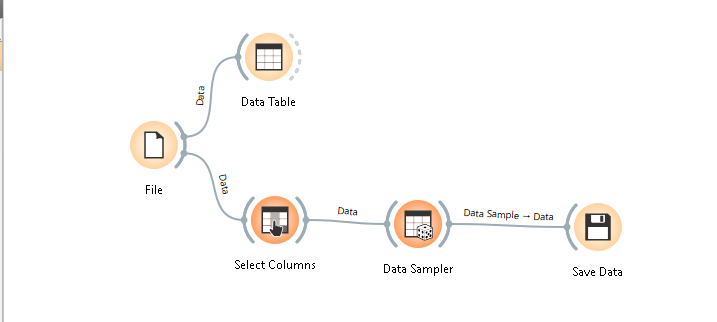

In [ ]:
d4f1 = pd.read_csv("/content/sample_data/Plant_1_Generation_Data_SAMPLE.csv")

In [ ]:
#Carregue a amostra e renomeie as principais variáveis para nomes mais claros
# como Potencia_CC, Potencia_CA e Geracao_Diaria.
d4f1.rename(columns={'DC_POWER':  'Potencia_CC',
                    'AC_POWER' : 'Potencia_CA',
                    'DAILY_YIELD' : 'Geracao_Diaria',
                    'TOTAL_YIELD' : 'Geracao_Total',}, inplace = True)

In [ ]:
# Apresente head(), shape, info() e describe().
d4f1.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,Potencia_CC,Potencia_CA,Geracao_Diaria,Geracao_Total
0,10-06-2020 19:00,4135001,uHbuxQJl8lW7ozc,0.00,0.000,6645.000,7240508.000
1,28-05-2020 00:15,4135001,rGa61gmuvPhdLxV,0.00,0.000,0.000,7206549.000
2,17-05-2020 15:15,4135001,sjndEbLyjtCKgGv,7333.88,718.062,6442.000,7036055.000
3,01-06-2020 04:15,4135001,ih0vzX44oOqAx2f,0.00,0.000,0.000,6308232.000
4,17-05-2020 09:00,4135001,z9Y9gH1T5YWrNuG,7665.50,750.438,961.375,7021701.375


In [ ]:
print(f"Número de linhas: {d4f1.shape[0]}")
print(f"Número de Colunas: {d4f1.shape[1]}")

Número de linhas: 6878
Número de Colunas: 7


In [ ]:
d4f1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6878 entries, 0 to 6877
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   DATE_TIME       6878 non-null   object 
 1   PLANT_ID        6878 non-null   int64  
 2   SOURCE_KEY      6878 non-null   object 
 3   Potencia_CC     6878 non-null   float64
 4   Potencia_CA     6878 non-null   float64
 5   Geracao_Diaria  6878 non-null   float64
 6   Geracao_Total   6878 non-null   float64
dtypes: float64(4), int64(1), object(2)
memory usage: 376.3+ KB


In [ ]:
d4f1.describe()

,PLANT_ID,Potencia_CC,Potencia_CA,Geracao_Diaria,Geracao_Total
count,6878.0,6878.000000,6878.000000,6878.000000,6.878000e+03
mean,4135001.0,3129.067891,306.039336,3332.737488,6.979532e+06
std,0.0,4019.384974,392.772722,3144.921092,4.156097e+05
min,4135001.0,0.000000,0.000000,0.000000,6.183645e+06
25%,4135001.0,0.000000,0.000000,0.000000,6.512002e+06
50%,4135001.0,333.062500,32.193750,2717.690000,7.143812e+06
75%,4135001.0,6370.115000,623.991750,6332.000000,7.267122e+06
max,4135001.0,14300.300000,1394.290000,9163.000000,7.846821e+06


In [ ]:
#Determine o maior consumo de eletrodomésticos registrado na amostra.
CMAX4 = d4f1['Potencia_CA'].max()
print(f'A potência máxima de CA é: {CMAX4:.2f} KW')

A potência máxima de CA é: 1394.29 KW


In [ ]:
#Calcule um limiar correspondente a 70% da potência CA máxima.
PCA70 = 0.7 * CMAX4
print(f'O limiar de 70% da demanda máxima é {PCA70:.2f} KW')

O limiar de 70% da demanda máxima é 976.00 KW


In [ ]:
#Crie um DataFrame contendo somente registros acima desse limite e calcule sua quantidade e percentual.
d4f2 = d4f1[d4f1['Potencia_CA'] > PCA70]
d4f2.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,Potencia_CC,Potencia_CA,Geracao_Diaria,Geracao_Total
11,26-05-2020 12:15,4135001,bvBOhCH3iADSZry,11830.1,1153.83,4028.14,6396364.143
46,15-06-2020 14:30,4135001,wCURE6d3bPkepu2,10571.3,1032.07,5366.57,7015064.571
48,25-05-2020 10:15,4135001,z9Y9gH1T5YWrNuG,11050.1,1079.86,2174.29,7082812.286
72,13-06-2020 11:30,4135001,7JYdWkrLSPkdwr4,11094.5,1082.44,3570.25,7815987.250
76,07-06-2020 13:00,4135001,VHMLBKoKgIrUVDU,12663.4,1234.69,4976.71,7382965.714


In [ ]:
print(f"Número de linhas do novo DATAFRAME: {d4f2.shape[0]}")
print(f"Número de Colunas do novo DATAFRAME: {d4f2.shape[1]}")

Número de linhas do novo DATAFRAME: 609
Número de Colunas do novo DATAFRAME: 7


In [ ]:
Porcentagem_4 = 1185 / 13756 * 100

print(f'O percentual da amostra que estão acima do limiar de 70% do maximo de consumo é aproximadamente: {Porcentagem_4:.2f} %')

O percentual da amostra que estão acima do limiar de 70% do maximo de consumo é aproximadamente: 8.61 %


In [ ]:
d4f2['SOURCE_KEY'].value_counts()

,count
SOURCE_KEY,
adLQvlD726eNBSB,38
1IF53ai7Xc0U56Y,34
pkci93gMrogZuBj,33
ZoEaEvLYb1n2sOq,33
sjndEbLyjtCKgGv,32
VHMLBKoKgIrUVDU,32
ZnxXDlPa8U1GXgE,31
McdE0feGgRqW7Ca,31
WRmjgnKYAwPKWDb,30


## Identifique qual inversor aparece com maior frequência nos registros de alta geração e descreva o que esse resultado permite observar, sem concluir desempenho ou falha apenas com esse recorte.


Com base nos registros de alta geração (aqueles acima de 70% da potência CA máxima), o inversor `'adLQvlD726eNBSB'` é o que aparece com maior frequência. Isso indica que, nos momentos de maior produção de energia da usina, este inversor esteve presente no maior número de ocorrências que atingiram esse limiar. Essa observação não permite concluir sobre seu desempenho ou falha, mas sim que ele é frequentemente ativo em períodos de alta produção. É um ponto de partida para investigações futuras, como comparar seu comportamento com outros inversores ou analisar as condições operacionais específicas durante esses picos de geração.

##**Dataset 5 — Wind & Solar Energy Production (Kaggle)**

Fonte: https://www.kaggle.com/datasets/ahmeduzaki/wind-and-solar-energy-production-dataset?resource=download$0

Situação:

Um operador de um portfólio de fontes renováveis deseja comparar a ocorrência de períodos de alta produção solar e alta produção eólica. Como as duas fontes possuem escalas próprias, cada uma deverá ser comparada com o seu próprio valor máximo.

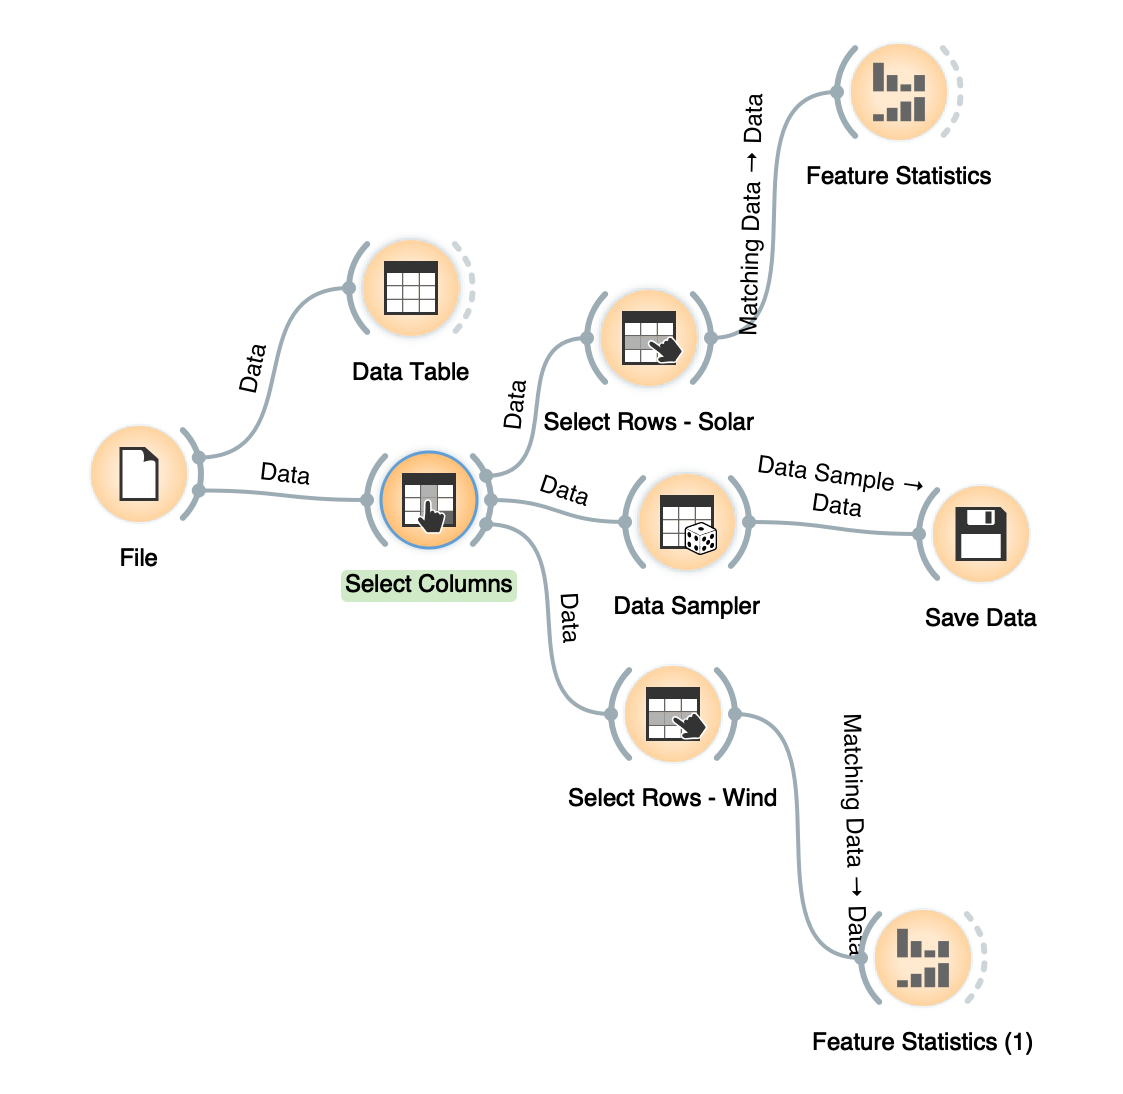

In [ ]:
# Carregando amostra
d5f1 = pd.read_csv("/content/wind_solar_amostra_SAMPLE.csv", skiprows=[1, 2])
d5f1.head()

,Start_Hour,End_Hour,Source,Day_of_Year,Day_Name,Month_Name,Season,Production,Date
0,18.0,19.0,Wind,121.0,Saturday,May,Spring,4262.0,5/1/2021
1,5.0,6.0,Wind,241.0,Tuesday,August,Summer,2228.0,8/29/2023
2,6.0,7.0,Wind,186.0,Wednesday,July,Summer,9096.0,7/5/2023
3,5.0,6.0,Wind,194.0,Friday,July,Summer,4928.0,7/12/2024
4,15.0,16.0,Wind,290.0,Friday,October,Fall,3554.0,10/16/2020


In [ ]:
print(f"Número de linhas: {d5f1.shape[0]}")
print(f"Número de Colunas: {d5f1.shape[1]}")

Número de linhas: 10373
Número de Colunas: 9


In [ ]:
d5f1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10373 entries, 0 to 10372
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Start_Hour   10373 non-null  float64
 1   End_Hour     10373 non-null  float64
 2   Source       10373 non-null  object 
 3   Day_of_Year  10373 non-null  float64
 4   Day_Name     10373 non-null  object 
 5   Month_Name   10373 non-null  object 
 6   Season       10373 non-null  object 
 7   Production   10373 non-null  float64
 8   Date         10373 non-null  object 
dtypes: float64(4), object(5)
memory usage: 729.5+ KB


In [ ]:
d5f1.describe()

,Start_Hour,End_Hour,Day_of_Year,Production
count,10373.000000,10373.000000,10373.000000,10373.000000
mean,11.486937,11.468910,180.382724,6248.254989
std,6.944351,6.941114,103.427907,4003.074157
min,0.000000,0.000000,1.000000,92.000000
25%,5.000000,5.000000,92.000000,3081.000000
50%,12.000000,12.000000,180.000000,5390.000000
75%,18.000000,18.000000,268.000000,8620.000000
max,23.000000,23.000000,366.000000,23081.000000


In [ ]:
# Conferindo as categorias existentes em Source antes de seguir
d5f1['Source'].value_counts()

,count
Source,
Wind,8497
Solar,1875
Mixed,1


In [ ]:
# Removendo o registro com rótulo inválido(Mixed) em Source
d5f1 = d5f1[d5f1['Source'] != 'Mixed']
d5f1['Source'].value_counts()

,count
Source,
Wind,8497
Solar,1875


In [ ]:
# 1. Renomeie as variáveis principais para Geracao_Solar e Geracao_Eolica.
# Renomeamos Production para Geracao
# E depois separamos em dois DataFrames, um para cada fonte de energia.
d5f1 = d5f1.rename(columns={'Production': 'Geracao'})

d5f1_solar = d5f1[d5f1['Source'] == 'Solar'].copy()
d5f1_eolica = d5f1[d5f1['Source'] == 'Wind'].copy()

d5f1_solar.head()


,Start_Hour,End_Hour,Source,Day_of_Year,Day_Name,Month_Name,Season,Geracao,Date
10,10.0,11.0,Solar,257.0,Friday,September,Fall,8382.0,9/13/2024
14,9.0,10.0,Solar,251.0,Monday,September,Fall,3178.0,9/8/2025
15,10.0,11.0,Solar,183.0,Friday,July,Summer,3568.0,7/2/2021
31,14.0,15.0,Solar,324.0,Saturday,November,Fall,1956.0,11/20/2021
43,14.0,15.0,Solar,6.0,Thursday,January,Winter,5505.0,1/6/2022


In [ ]:
# 2. Determine o valor máximo registrado para cada fonte.
CMAX_SOLAR = d5f1_solar['Geracao'].max()
CMAX_EOLICA = d5f1_eolica['Geracao'].max()

print(f'Geração solar máxima: {CMAX_SOLAR:.2f}')
print(f'Geração eólica máxima: {CMAX_EOLICA:.2f}')

Geração solar máxima: 15482.00
Geração eólica máxima: 23081.00


In [ ]:
# 3. Calcule separadamente 70% do máximo solar e 70% do máximo eólico.
P70_SOLAR = 0.70 * CMAX_SOLAR
P70_EOLICA = 0.70 * CMAX_EOLICA

print(f'Limiar de 70% (Solar): {P70_SOLAR:.2f}')
print(f'Limiar de 70% (Eólica): {P70_EOLICA:.2f}')

Limiar de 70% (Solar): 10837.40
Limiar de 70% (Eólica): 16156.70


In [ ]:
# 4. Crie um DataFrame para registros de alta geração solar
# e outro para registros de alta geração eólica.
d5f1_alta_solar = d5f1_solar[d5f1_solar['Geracao'] > P70_SOLAR]
d5f1_alta_eolica = d5f1_eolica[d5f1_eolica['Geracao'] > P70_EOLICA]

d5f1_alta_solar.head()

,Start_Hour,End_Hour,Source,Day_of_Year,Day_Name,Month_Name,Season,Geracao,Date
126,15.0,16.0,Solar,209.0,Monday,July,Summer,11370.0,7/28/2025
300,12.0,13.0,Solar,131.0,Friday,May,Spring,11083.0,5/10/2024
484,14.0,15.0,Solar,213.0,Friday,August,Summer,12382.0,8/1/2025
531,12.0,13.0,Solar,223.0,Monday,August,Summer,11811.0,8/11/2025
619,13.0,14.0,Solar,233.0,Tuesday,August,Summer,11619.0,8/20/2024


In [ ]:
# 5. Conte os registros de cada DataFrame e calcule seus respectivos percentuais
# (percentual calculado em relação ao total de registros da própria fonte).
pct_solar = len(d5f1_alta_solar) / len(d5f1_solar) * 100
pct_eolica = len(d5f1_alta_eolica) / len(d5f1_eolica) * 100

print(f'Alta geração solar: {len(d5f1_alta_solar)} registros ({pct_solar:.2f}% da amostra solar)')
print(f'Alta geração eólica: {len(d5f1_alta_eolica)} registros ({pct_eolica:.2f}% da amostra eólica)')

Alta geração solar: 66 registros (3.52% da amostra solar)
Alta geração eólica: 234 registros (2.75% da amostra eólica)


### 6. Compare qual fonte aparece com maior frequência acima de 70% do seu próprio máximo

A geração solar apresenta uma frequência relativa maior de registros de alta geração (cerca de 3,52% dos seus próprios registros) do que a eólica (cerca de 2,75%). Isso sugere que, proporcionalmente, a fonte solar atinge picos próximos do seu máximo com um pouco mais de frequência que a eólica nesta amostra, mesmo a eólica tendo o maior valor absoluto de geração registrado.

### 7. Por que não seria adequado usar o mesmo valor numérico como limite para as duas fontes

A geração solar máxima na amostra é de aproximadamente 15.482, enquanto a eólica chega a aproximadamente 23.081, oque significa que, as duas fontes operam em escalas bem diferentes. Se fosse usado um único valor fixo (por exemplo, um limite absoluto de geração) como corte para as duas, ele favoreceria artificialmente a fonte de maior escala (eólica), classificando poucos ou nenhum registro solar como "alta geração", mesmo que a usina solar estivesse operando próxima do seu próprio pico. Por isso o critério relativo (70% do máximo de cada fonte) é o correto: ele compara cada fonte com o seu próprio comportamento, tornando a comparação justa entre as duas.

In [ ]:
print('Verificando valores ausentes no df1:')
df1.isnull().sum()

## Dataset 6 — Individual Household Electric Power Consumption

fonte:https://archive.ics.uci.edu/dataset/235/individual+household+electric+power+consumption

Situação

Uma residência possui monitoramento elétrico detalhado e deseja identificar episódios de demanda elevada que também apresentem corrente acima do comportamento médio. O dataset é o mesmo utilizado como referência em aula, mas o critério de análise será diferente.

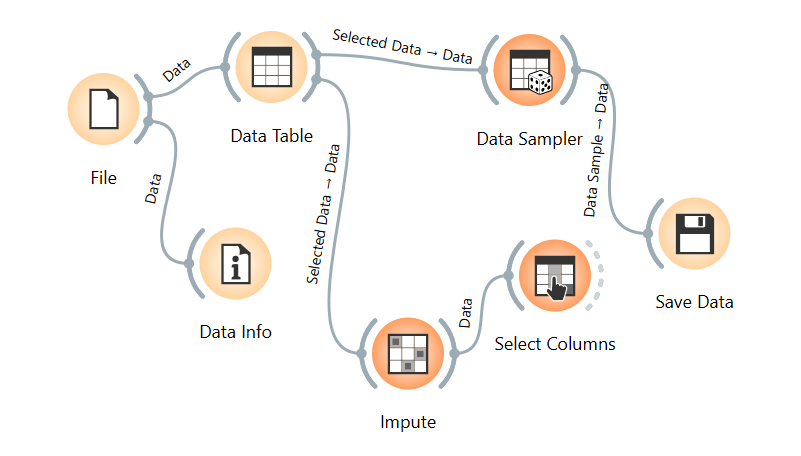

In [ ]:
d6f1 = pd.read_csv("/household_power_consumption_SAMPLE.csv")

In [ ]:
##Carregue a nova amostra e organize os atributos utilizando nomes mais simples.
d6f1 = d6f1.rename(columns={
    "Global_active_power": "Potencia_Ativa",
    "Global_reactive_power": "Potencia_Reativa",
    "Voltage": "Tensao",
    "Global_intensity": "Corrente",
    "Sub_metering_1": "Sub1",
    "Sub_metering_2": "Sub2",
    "Sub_metering_3": "Sub3"
})



In [ ]:
##primeiras linhas.
d6f1.head()

,Potencia_Ativa,Potencia_Reativa,Tensao,Corrente,Sub1,Sub2,Sub3
0,1.502,0.074,240.17,6.4,0.0,0.0,18.0
1,0.374,0.264,245.50,1.8,0.0,2.0,0.0
2,0.620,0.300,239.85,3.0,0.0,1.0,1.0
3,0.280,0.200,235.72,1.4,0.0,0.0,0.0
4,1.372,0.054,243.95,5.6,0.0,0.0,18.0


In [ ]:
##dimensões.
d6f1.shape

(204928, 7)

In [ ]:
##informações das colunas.
d6f1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204928 entries, 0 to 204927
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Potencia_Ativa    204928 non-null  float64
 1   Potencia_Reativa  204928 non-null  float64
 2   Tensao            204928 non-null  float64
 3   Corrente          204928 non-null  float64
 4   Sub1              204928 non-null  float64
 5   Sub2              204928 non-null  float64
 6   Sub3              204928 non-null  float64
dtypes: float64(7)
memory usage: 10.9 MB


In [ ]:
##estatísticas.
d6f1.describe()

,Potencia_Ativa,Potencia_Reativa,Tensao,Corrente,Sub1,Sub2,Sub3
count,204928.000000,204928.000000,204928.000000,204928.000000,204928.000000,204928.000000,204928.000000
mean,1.093172,0.124124,240.828559,4.634430,1.136463,1.317780,6.477397
std,1.063330,0.112645,3.245863,4.469326,6.200722,5.909236,8.452212
min,0.076000,0.000000,224.680000,0.200000,0.000000,0.000000,0.000000
25%,0.308000,0.048000,238.990000,1.400000,0.000000,0.000000,0.000000
50%,0.600000,0.100000,241.000000,2.600000,0.000000,0.000000,1.000000
75%,1.528000,0.196000,242.870000,6.400000,0.000000,1.000000,17.000000
max,10.536000,1.082000,253.750000,45.800000,83.000000,79.000000,31.000000


In [ ]:
##potência ativa máxima
PMAX6 = d6f1["Potencia_Ativa"].max()

print("Potência ativa máxima:", PMAX6)

Potência ativa máxima: 10.536


In [ ]:
##calculando 75% da potência máxima
limite75 = PMAX6 * 0.75

print("Limite de 75%:", limite75)

Limite de 75%: 7.901999999999999


In [ ]:
##DataFrame com potência alta
d6f2 = d6f1[d6f1["Potencia_Ativa"] > limite75]

d6f2.head()

,Potencia_Ativa,Potencia_Reativa,Tensao,Corrente,Sub1,Sub2,Sub3
3132,8.540,0.238,236.23,36.0,80.0,35.0,17.0
3630,8.278,0.088,231.50,35.6,0.0,71.0,17.0
10339,8.026,0.066,236.45,33.8,37.0,73.0,18.0
11695,8.102,0.190,229.31,35.4,35.0,35.0,17.0
27983,10.290,0.302,230.90,44.6,35.0,66.0,17.0


In [ ]:
##Quantidade de registros
quantidade = len(d6f2)

print("Quantidade:", quantidade)

Quantidade: 58


In [ ]:
##Percentual
percentual = quantidade / len(d6f1) * 100

print(f"Percentual: {percentual:.2f}%")

Percentual: 0.03%


In [ ]:
##Calculando a corrente média
corrente_media = d6f1["Corrente"].mean()

print("Corrente média:", corrente_media)
##Esse valor representa o comportamento médio da corrente elétrica na amostra.

Corrente média: 4.6344296533416625


In [ ]:
#Crie um segundo DataFrame contendo simultaneamente potência ativa acima de 75% do máximo e corrente acima da média.


In [ ]:
d6f3 = d6f1[(d6f1["Potencia_Ativa"] > limite75) &
            (d6f1["Corrente"] > corrente_media)]

d6f3.head()

,Potencia_Ativa,Potencia_Reativa,Tensao,Corrente,Sub1,Sub2,Sub3
3132,8.540,0.238,236.23,36.0,80.0,35.0,17.0
3630,8.278,0.088,231.50,35.6,0.0,71.0,17.0
10339,8.026,0.066,236.45,33.8,37.0,73.0,18.0
11695,8.102,0.190,229.31,35.4,35.0,35.0,17.0
27983,10.290,0.302,230.90,44.6,35.0,66.0,17.0


In [ ]:
d6f3.shape

(58, 7)

In [ ]:
quantidade_d6f3 = len(d6f3)
percentual_d6f3 = quantidade_d6f3 / len(d6f1) * 100

print(f"Quantidade de registros com alta potência e corrente acima da média: {quantidade_d6f3}")
print(f"Percentual da amostra: {percentual_d6f3:.2f}%")

Quantidade de registros com alta potência e corrente acima da média: 58
Percentual da amostra: 0.03%


### Comparação dos DataFrames d6f2 e d6f3

- **d6f2**: Registros com potência ativa acima de 75% do máximo.
  - Quantidade: 58 registros
  - Percentual da amostra: 0.03%

- **d6f3**: Registros com potência ativa acima de 75% do máximo **E** corrente acima da média.
  - Quantidade: 58 registros
  - Percentual da amostra: 0.03%

**Efeito da inclusão da corrente como segunda condição:**

Ao incluir a condição de que a corrente também deve estar acima da média (`corrente_media = 4.63`), o número de registros no DataFrame não foi alterado. Isso indica que **todos** os registros que já apresentavam potência ativa acima de 75% do máximo (`d6f2`) já possuíam, simultaneamente, uma corrente acima da média. Ou seja, no período analisado por essa amostra, os momentos de pico de consumo de potência ativa sempre coincidiram com momentos de corrente elétrica elevada.